In [13]:
import numpy as np
from pymoo.core.problem import ElementwiseProblem
from pymoo.algorithms.moo.nsga2 import NSGA2
from pymoo.operators.crossover.sbx import SBX
from pymoo.operators.mutation.pm import PM
from pymoo.operators.sampling.rnd import FloatRandomSampling
from pymoo.optimize import minimize
import matplotlib.pyplot as plt

In [10]:


class MyProblem(ElementwiseProblem):

    def __init__(self):
        super().__init__(n_var=1,
                         n_obj=2,
                         
                         xl=-5,
                         xu=5)

    def _evaluate(self, x, out, *args, **kwargs):
        f1 = x**2
        f2 = (x-2)**2
        out["F"] = [f1,f2]
       


problem = MyProblem()

algorithm = NSGA2(
    n_max_gen = 100,
    pop_size=40,
    n_offsprings=10,
    eliminate_duplicates=True,
    save_history=True
)

In [11]:
res = minimize(problem,
               algorithm,
               
               seed=1,
               save_history=True,
               verbose=True)

X = res.X
F = res.F

n_gen  |  n_eval  | n_nds  |      eps      |   indicator  
     1 |       40 |      9 |             - |             -
     2 |       50 |     12 |  0.0070644190 |             f
     3 |       60 |     16 |  0.0049338467 |             f
     4 |       70 |     20 |  0.0705120687 |         nadir
     5 |       80 |     23 |  0.0039497819 |         ideal
     6 |       90 |     30 |  0.0035981612 |         ideal
     7 |      100 |     36 |  0.0122115275 |             f
     8 |      110 |     40 |  0.0037286605 |             f
     9 |      120 |     40 |  0.0415934769 |         nadir
    10 |      130 |     40 |  0.0081748150 |             f
    11 |      140 |     40 |  0.0031054630 |         nadir
    12 |      150 |     40 |  0.0013536055 |             f
    13 |      160 |     40 |  0.0020747999 |             f
    14 |      170 |     40 |  0.4080375037 |         nadir
    15 |      180 |     40 |  0.0041318712 |         nadir
    16 |      190 |     40 |  0.0048185944 |         ide

In [22]:
res.pop.get("F")[:,0]

array([3.99969457e+00, 2.22890441e-10, 3.12010735e-02, 2.81021615e-03,
       9.18186671e-01, 1.10731510e-01, 4.75796108e-01, 3.00642437e+00,
       1.29364610e+00, 1.80373427e+00, 2.41545561e-01, 1.03085735e+00,
       1.61908963e+00, 1.88150274e-01, 7.36097610e-01, 2.46256531e+00,
       2.28898416e+00, 1.42030402e-01, 5.57740429e-02, 5.36201129e-01,
       3.77554839e+00, 3.58546053e-01, 1.43484833e+00, 2.13848656e+00,
       3.18064285e+00, 1.50845250e+00, 2.76513699e+00, 3.29116976e+00,
       2.04651790e+00, 3.63108929e+00, 7.19690525e-01, 1.16308317e+00,
       3.04763188e-01, 1.15202844e+00, 3.43763605e+00, 6.20590032e-01,
       6.28815773e-01, 5.50386856e-02, 2.62899337e+00, 1.93514012e+00])

In [12]:
print(res.X)
print(res.F)

[[1.99992364e+00]
 [1.49295158e-05]
 [1.76638256e-01]
 [5.30114719e-02]
 [9.58220575e-01]
 [3.32763444e-01]
 [6.89779753e-01]
 [1.73390437e+00]
 [1.13738564e+00]
 [1.34303175e+00]
 [4.91472848e-01]
 [1.01531145e+00]
 [1.27243453e+00]
 [4.33762924e-01]
 [8.57961310e-01]
 [1.56925629e+00]
 [1.51293892e+00]
 [3.76869210e-01]
 [2.36165287e-01]
 [7.32257556e-01]
 [1.94307704e+00]
 [5.98787152e-01]
 [1.19785155e+00]
 [1.46235651e+00]
 [1.78343569e+00]
 [1.22819074e+00]
 [1.66287011e+00]
 [1.81415814e+00]
 [1.43056559e+00]
 [1.90554173e+00]
 [8.48345758e-01]
 [1.07846334e+00]
 [5.52053610e-01]
 [1.07332588e+00]
 [1.85408631e+00]
 [7.87775369e-01]
 [7.92979049e-01]
 [2.34603251e-01]
 [1.62141709e+00]
 [1.39109314e+00]]
[[3.99969457e+00 5.83052314e-09]
 [2.22890441e-10 3.99994028e+00]
 [3.12010735e-02 3.32464805e+00]
 [2.81021615e-03 3.79076433e+00]
 [9.18186671e-01 1.08530437e+00]
 [1.10731510e-01 2.77967773e+00]
 [4.75796108e-01 1.71667709e+00]
 [3.00642437e+00 7.08068839e-02]
 [1.29364610e+0

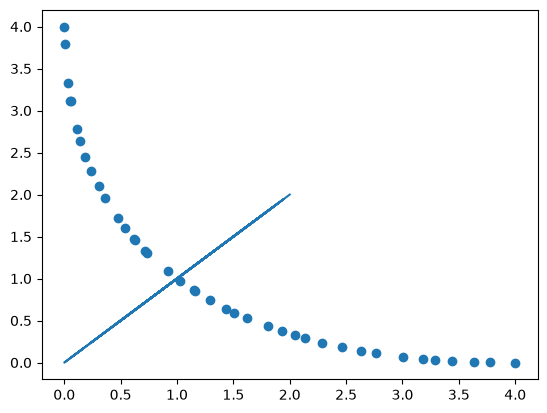

In [24]:
obj1 = res.pop.get("F")[:,0]
obj2= res.pop.get("F")[:,1]
vars = res.pop.get("X")
plt.scatter(obj1,obj2)
plt.plot(vars,vars)